# CBP-NG Branch Predictor Profiling & Architectural Analysis

This notebook performs Exploratory Data Analysis (EDA) on the 168 trace dataset and evaluates the performance (IPC, MPKI, VFS speedup) of all branch predictor families under fixed hardware budgets (8KB and 16KB) using optimized configurations.

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set paths relative to the profiling directory
REPO_ROOT = Path("..").resolve()
OUTPUTS_DIR = REPO_ROOT / "profiling" / "outputs"
TRACE_CHAR_CSV = OUTPUTS_DIR / "trace_characteristics.csv"
COMP_RESULTS_CSV = OUTPUTS_DIR / "full_comparison_results.csv"

# Enable nice styling
plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "default")
pd.set_option("display.max_columns", None)

## 1. Exploratory Data Analysis (EDA) of the Traces

Here, we load `trace_characteristics.csv` containing the branch statistics for all 168 traces, and show:
- Overall dataset distributions (Min, Median, Max, Quartiles)
- Detailed characteristics of the 12 representative traces selected for full predictor evaluations.

In [17]:
# Load trace characteristics
df_traces = pd.read_csv(TRACE_CHAR_CSV)

# Compute general statistics over the whole set of 168 traces
summary_metrics = ['br_density', 'cond_taken_rate', 'backward_rate', 'indirect_rate', 'unique_cond_pcs']
summary_stats = df_traces[summary_metrics].describe(percentiles=[0.25, 0.5, 0.75]).T
summary_stats = summary_stats[['min', '25%', '50%', '75%', 'max']]
summary_stats.columns = ['Min', '25% Quartile', 'Median', '75% Quartile', 'Max']

# Format percentage columns
for col in ['Min', '25% Quartile', 'Median', '75% Quartile', 'Max']:
    summary_stats.loc[['br_density', 'cond_taken_rate', 'backward_rate', 'indirect_rate'], col] = \
        summary_stats.loc[['br_density', 'cond_taken_rate', 'backward_rate', 'indirect_rate'], col].apply(lambda x: f"{x:.1%}")
    summary_stats.loc['unique_cond_pcs', col] = f"{int(float(summary_stats.loc['unique_cond_pcs', col])):,}"

print("=== 168 TRACE DATASET GENERAL DISTRIBUTION ===")
display(summary_stats)
# print(summary_stats.to_latex(index=True,
#                   formatters={"name": str.upper},
#                   float_format="{:.1f}".format,
#                   ))


=== 168 TRACE DATASET GENERAL DISTRIBUTION ===


/tmp/ipykernel_11416/740333706.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1.5%' '6.5%' '0.5%' '0.0%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_stats.loc[['br_density', 'cond_taken_rate', 'backward_rate', 'indirect_rate'], col] = \
/tmp/ipykernel_11416/740333706.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['15.4%' '33.2%' '10.6%' '2.7%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_stats.loc[['br_density', 'cond_taken_rate', 'backward_rate', 'indirect_rate'], col] = \
/tmp/ipykernel_11416/740333706.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['18.9%' '39.7%' '14.9%' '8.7%']' has dtype incompatible wit

,Min,25% Quartile,Median,75% Quartile,Max
br_density,1.5%,15.4%,18.9%,20.7%,33.3%
cond_taken_rate,6.5%,33.2%,39.7%,45.8%,99.2%
backward_rate,0.5%,10.6%,14.9%,23.1%,79.7%
indirect_rate,0.0%,2.7%,8.7%,14.5%,27.2%
unique_cond_pcs,40,567,"1,553","10,422","66,766"


### Characteristics of Selected 12 Evaluation Traces
Let's filter the selected traces used in the simulation comparisons.

In [ ]:
selected_traces = [
    "fp_28", "nodejs-misc-util_7039", "compress_44", "web_99", "web_13", "infra_32",
    "tomcat-wrk2-panel.3289_0", "int_48", "505-mcf-1_14364", "compress_47", "int_210",
    "java16-specjbb-4k.23837_0"
]

df_selected = df_traces[df_traces["trace"].isin(selected_traces)].copy()
# Format values
df_selected["instructions"] = df_selected["instructions"].apply(lambda x: f"{x:,}")
df_selected["br_density"] = df_selected["br_density"].apply(lambda x: f"{x:.2%}")
df_selected["cond_taken_rate"] = df_selected["cond_taken_rate"].apply(lambda x: f"{x:.2%}")
df_selected["backward_rate"] = df_selected["backward_rate"].apply(lambda x: f"{x:.2%}")
df_selected["uncond_rate"] = df_selected["uncond_rate"].apply(lambda x: f"{x:.2%}")
df_selected["indirect_rate"] = df_selected["indirect_rate"].apply(lambda x: f"{x:.2%}")
df_selected["unique_cond_pcs"] = df_selected["unique_cond_pcs"].apply(lambda x: f"{x:,}")

cols = ["trace", "instructions", "br_density", "cond_taken_rate", "backward_rate", "uncond_rate", "indirect_rate", "unique_cond_pcs"]
print("=== SELECTED 12 EVALUATION TRACES CHARACTERISTICS ===")
display(df_selected[cols])

# print(df_selected[cols].to_latex(index=False,
#                   formatters={"name": str.upper},
#                   float_format="{:.1f}".format,
# ))

=== SELECTED 12 EVALUATION TRACES CHARACTERISTICS ===


,trace,instructions,br_density,cond_taken_rate,backward_rate,uncond_rate,indirect_rate,unique_cond_pcs
1,505-mcf-1_14364,"21,532,609",11.63%,39.65%,23.28%,6.92%,0.03%,301
18,compress_44,"40,000,000",24.77%,99.23%,49.59%,0.21%,0.02%,382
19,compress_47,"40,000,000",13.27%,39.65%,28.70%,7.67%,1.20%,"1,566"
32,fp_28,"39,000,014",1.51%,86.38%,79.68%,0.71%,0.02%,40
45,infra_32,"39,000,014",23.61%,10.59%,0.47%,26.09%,12.88%,306
62,int_210,"39,000,050",15.38%,41.85%,17.89%,15.45%,4.04%,"1,170"
67,int_48,"39,000,046",16.86%,39.23%,32.71%,3.87%,0.00%,538
78,java16-specjbb-4k.23837_0,"21,044,473",13.55%,43.03%,14.01%,23.95%,10.25%,493
109,nodejs-misc-util_7039,"21,029,395",33.32%,33.33%,33.33%,0.02%,0.01%,274
140,tomcat-wrk2-panel.3289_0,"21,128,092",17.77%,54.14%,7.26%,37.45%,27.21%,"6,012"


\begin{tabular}{llllllll}
\toprule
trace & instructions & br_density & cond_taken_rate & backward_rate & uncond_rate & indirect_rate & unique_cond_pcs \\
\midrule
505-mcf-1_14364 & 21,532,609 & 11.63% & 39.65% & 23.28% & 6.92% & 0.03% & 301 \\
compress_44 & 40,000,000 & 24.77% & 99.23% & 49.59% & 0.21% & 0.02% & 382 \\
compress_47 & 40,000,000 & 13.27% & 39.65% & 28.70% & 7.67% & 1.20% & 1,566 \\
fp_28 & 39,000,014 & 1.51% & 86.38% & 79.68% & 0.71% & 0.02% & 40 \\
infra_32 & 39,000,014 & 23.61% & 10.59% & 0.47% & 26.09% & 12.88% & 306 \\
int_210 & 39,000,050 & 15.38% & 41.85% & 17.89% & 15.45% & 4.04% & 1,170 \\
int_48 & 39,000,046 & 16.86% & 39.23% & 32.71% & 3.87% & 0.00% & 538 \\
java16-specjbb-4k.23837_0 & 21,044,473 & 13.55% & 43.03% & 14.01% & 23.95% & 10.25% & 493 \\
nodejs-misc-util_7039 & 21,029,395 & 33.32% & 33.33% & 33.33% & 0.02% & 0.01% & 274 \\
tomcat-wrk2-panel.3289_0 & 21,128,092 & 17.77% & 54.14% & 7.26% & 37.45% & 27.21% & 6,012 \\
web_13 & 38,999,811 & 16.47% & 31.0

## 2. Block Predictor Results (Fixed Budget: 8KB and 16KB)

Now we load the simulation comparison results and analyze the block-based predictors (`mode == "Block"`).

In [25]:
# Load simulation results
df_results = pd.read_csv(COMP_RESULTS_CSV)

# Filter block predictors
df_block = df_results[df_results['mode'] == 'Block'].copy()

# Pivot to show Mean VFS, Mean MPKI, and Mean IPC per predictor configuration per budget
block_pivot = df_block.groupby(['budget', 'pred_name', 'expr', 'size_bits'])[['vfs', 'mpki', 'ipc', 'epi']].mean().reset_index()
block_pivot = block_pivot.sort_values(by=['budget', 'vfs'], ascending=[True, False])

print("=== BLOCK PREDICTOR AVERAGE PERFORMANCE (8KB & 16KB) ===")
display(block_pivot)

=== BLOCK PREDICTOR AVERAGE PERFORMANCE (8KB & 16KB) ===


,budget,pred_name,expr,size_bits,vfs,mpki,ipc,epi
9,16KB,tage_simpleL,"tage_simpleL<9,16,64,4,16,64,3,4>",122880,0.698795,5.417200,4.704776,1145.500000
10,16KB,tage_simple_uL,"tage_simple_uL<9,16,64,4,16,64,3,4>",124416,0.666629,4.188958,4.265601,933.416667
3,16KB,gshareL,"gshare_simpleL<12,12,2,4>",131072,0.658647,4.926783,3.493388,145.500000
2,16KB,gapL,"gapL<10,2,2,4>",131072,0.652502,5.282767,3.482910,143.500000
1,16KB,gagL,"gagL<12,2,4>",131072,0.647204,5.648175,3.474998,144.083333
0,16KB,bimodeL,"bimodeL<11,12,10,2,4>",131072,0.645192,4.895942,3.416849,414.500000
6,16KB,papL,"papL<8,10,3,2,4>",73728,0.609621,6.817800,3.261647,255.500000
4,16KB,lxorL,"lxorL<12,5,4>",53248,0.594841,8.310742,3.271935,349.916667
5,16KB,pagL,"pagL<12,2,2,4>",131120,0.567165,8.926067,3.070983,240.833333
7,16KB,perceptronL_LI16,"perceptron_simpleL<8,3,8,83,4>",131072,0.374589,6.910167,1.736871,653.916667


### Block Predictor VFS Scores Per Trace Breakdown
Let's see the individual VFS scores of each block predictor configuration on every trace analyzed under both 8KB and 16KB budgets.

In [20]:
# Pivot to show VFS score per trace for Block Predictors at 8KB
block_8kb_traces = df_block[df_block['budget'] == '8KB'].pivot(index='pred_name', columns='trace', values='vfs')
block_8kb_traces['Mean'] = block_8kb_traces.mean(axis=1)
block_8kb_traces = block_8kb_traces.sort_values(by='Mean', ascending=False)

print("=== BLOCK PREDICTOR VFS SCORES PER TRACE (8KB) ===")
display(block_8kb_traces.round(4))

# Pivot to show VFS score per trace for Block Predictors at 16KB
block_16kb_traces = df_block[df_block['budget'] == '16KB'].pivot(index='pred_name', columns='trace', values='vfs')
block_16kb_traces['Mean'] = block_16kb_traces.mean(axis=1)
block_16kb_traces = block_16kb_traces.sort_values(by='Mean', ascending=False)

print("\n=== BLOCK PREDICTOR VFS SCORES PER TRACE (16KB) ===")
display(block_16kb_traces.round(4))

=== BLOCK PREDICTOR VFS SCORES PER TRACE (8KB) ===


trace,505-mcf-1_14364,compress_44,compress_47,fp_28,infra_32,int_210,int_48,java16-specjbb-4k.23837_0,nodejs-misc-util_7039,tomcat-wrk2-panel.3289_0,web_13,web_99,Mean
pred_name,,,,,,,,,,,,,
tage_simpleL,0.7237,0.5955,0.7650,0.7493,0.8734,0.5465,0.7056,0.8128,0.5241,0.6154,0.7563,0.8539,0.7101
tage_simple_uL,0.7275,0.4902,0.7549,0.7420,0.8633,0.5242,0.6314,0.7663,0.4493,0.5795,0.6991,0.8449,0.6727
gshareL,0.7044,0.3302,0.7546,1.0336,0.7383,0.5353,0.6906,0.7190,0.5409,0.5261,0.6545,0.6249,0.6544
gapL,0.6870,0.3303,0.7548,1.0338,0.7290,0.5317,0.6809,0.7129,0.5410,0.5247,0.6425,0.6007,0.6474
gagL,0.7053,0.3302,0.7547,1.0330,0.7072,0.5269,0.6857,0.7193,0.5410,0.5013,0.6272,0.5831,0.6429
bimodeL,0.6724,0.3243,0.7342,1.0327,0.7342,0.5095,0.6587,0.6935,0.5330,0.5396,0.6503,0.6154,0.6415
papL,0.6458,0.3268,0.6569,1.0317,0.7198,0.4324,0.6152,0.7067,0.5377,0.4801,0.5996,0.5811,0.6111
pagL,0.6517,0.3245,0.6396,1.0301,0.7099,0.4051,0.6001,0.7053,0.5352,0.4570,0.5799,0.5642,0.6002
lxorL,0.6236,0.3246,0.6514,1.0317,0.6983,0.3860,0.5929,0.6986,0.5353,0.4550,0.5832,0.5574,0.5948



=== BLOCK PREDICTOR VFS SCORES PER TRACE (16KB) ===


trace,505-mcf-1_14364,compress_44,compress_47,fp_28,infra_32,int_210,int_48,java16-specjbb-4k.23837_0,nodejs-misc-util_7039,tomcat-wrk2-panel.3289_0,web_13,web_99,Mean
pred_name,,,,,,,,,,,,,
tage_simpleL,0.7010,0.5897,0.7474,0.7635,0.8611,0.5316,0.6853,0.7877,0.5206,0.6134,0.7469,0.8374,0.6988
tage_simple_uL,0.7272,0.3750,0.7550,0.7616,0.8553,0.5392,0.5979,0.7829,0.4477,0.5850,0.7245,0.8482,0.6666
gshareL,0.7114,0.3292,0.7541,1.0333,0.7390,0.5511,0.6927,0.7210,0.5401,0.5457,0.6617,0.6243,0.6586
gapL,0.7019,0.3294,0.7548,1.0336,0.7294,0.5451,0.6891,0.7188,0.5402,0.5386,0.6467,0.6024,0.6525
gagL,0.7119,0.3293,0.7542,1.0327,0.7071,0.5428,0.6868,0.7213,0.5401,0.5157,0.6328,0.5917,0.6472
bimodeL,0.6834,0.3235,0.7343,1.0324,0.7344,0.5227,0.6657,0.6983,0.5322,0.5500,0.6506,0.6148,0.6452
papL,0.6442,0.3265,0.6585,1.0314,0.7239,0.4388,0.6129,0.7041,0.5374,0.4723,0.5824,0.5831,0.6096
lxorL,0.6236,0.3246,0.6514,1.0317,0.6983,0.3860,0.5929,0.6986,0.5353,0.4550,0.5832,0.5574,0.5948
pagL,0.6626,0.3254,0.6194,1.0294,0.6117,0.3705,0.5900,0.6183,0.5378,0.3953,0.5276,0.5181,0.5672


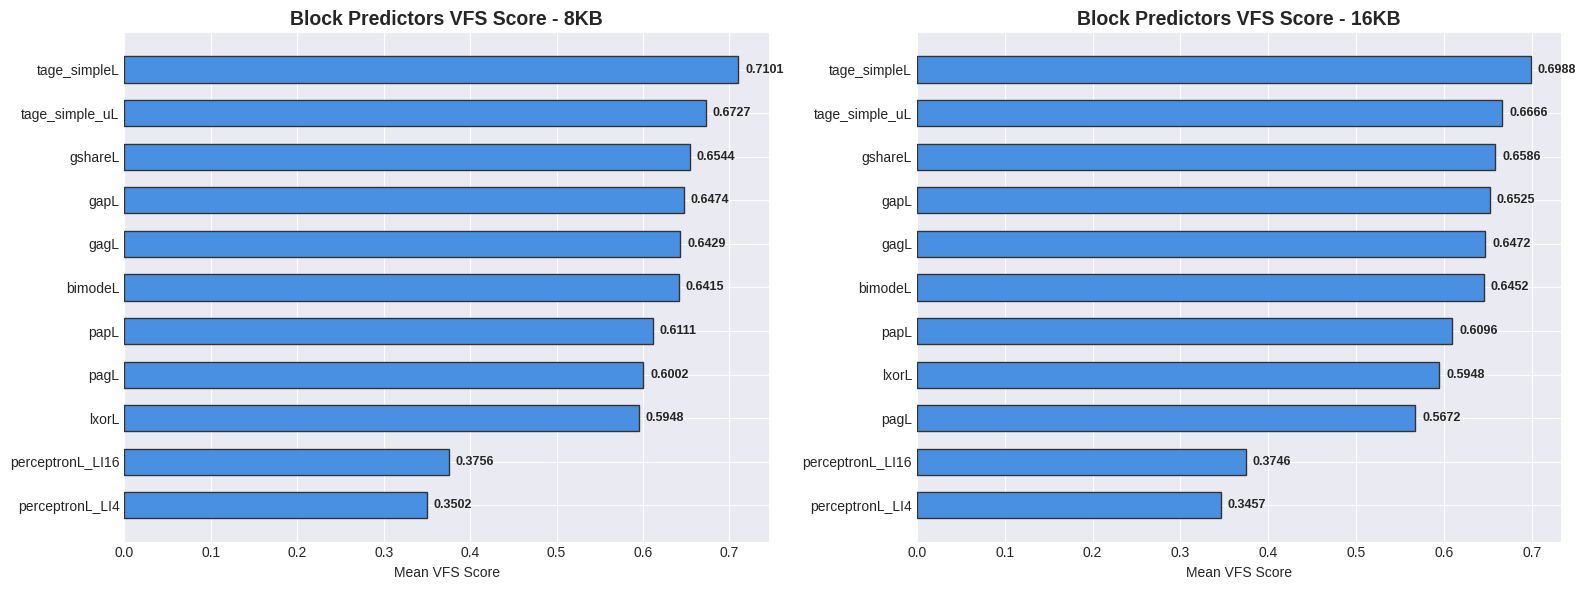

In [21]:
# Plot Block Predictor VFS Score Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for budget, ax in zip(["8KB", "16KB"], [ax1, ax2]):
    df_b = block_pivot[block_pivot['budget'] == budget].sort_values(by='vfs', ascending=True)
    bars = ax.barh(df_b['pred_name'], df_b['vfs'], color='#4A90E2', edgecolor='#333333', height=0.6)
    ax.set_title(f"Block Predictors VFS Score - {budget}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Mean VFS Score")
    for bar in bars:
        w = bar.get_width()
        ax.annotate(f"{w:.4f}", xy=(w, bar.get_y() + bar.get_height()/2), xytext=(5, 0),
                    textcoords="offset points", ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Scalar Predictor Results

Let's perform the same analysis for scalar-based predictors (`mode == "Scalar"`).

In [26]:
# Filter scalar predictors
df_scalar = df_results[df_results['mode'] == 'Scalar'].copy()

# Pivot to show Mean VFS, Mean MPKI, and Mean IPC per predictor configuration per budget
scalar_pivot = df_scalar.groupby(['budget', 'pred_name', 'expr', 'size_bits'])[['vfs', 'mpki', 'ipc', 'epi']].mean().reset_index()
scalar_pivot = scalar_pivot.sort_values(by=['budget', 'vfs'], ascending=[True, False])

print("=== SCALAR PREDICTOR AVERAGE PERFORMANCE (8KB & 16KB) ===")
display(scalar_pivot)

=== SCALAR PREDICTOR AVERAGE PERFORMANCE (8KB & 16KB) ===


,budget,pred_name,expr,size_bits,vfs,mpki,ipc,epi
8,16KB,tage_simple,"tage_simple<11,17,64,4,16,64,3>",129024,0.223935,5.012083,0.985119,2401.166667
3,16KB,gshare,"gshare_simple<16,16,2>",131072,0.121937,5.070683,0.497940,263.250000
2,16KB,gap,"gap<10,6,2>",131072,0.121222,6.263883,0.497417,257.500000
1,16KB,gag,"gag<16,2>",131072,0.120871,6.822158,0.497182,259.500000
0,16KB,bimode,"bimode<15,14,14,2>",131072,0.120612,4.677658,0.496413,694.250000
6,16KB,pap,"pap<8,10,7,2>",73728,0.119866,6.001758,0.493085,421.750000
7,16KB,perceptron,"perceptron_simple<10,15,8,83>",131072,0.119611,4.679058,0.497397,1368.583333
4,16KB,lxor,"lxor<11,7>",47104,0.119405,6.672042,0.493669,526.666667
5,16KB,pag,"pag<15,12,2>",126976,0.119090,6.082200,0.492089,628.333333
9,16KB,tage_simple_u,"tage_simple_u<11,16,64,4,16,64,3>",129024,0.118257,3.457125,0.492991,2047.416667


## 4. Scalar vs Block Speedup Analysis

Here, we compare the VFS scores of scalar predictors with their block-based counterparts and compute the speedup ratio on the average VFS score across all traces.

In [23]:
# Group by budget and family to get mean VFS of Scalar vs Block
family_vfs = df_results.groupby(['budget', 'family', 'mode'])['vfs'].mean().unstack().reset_index()
family_vfs['Speedup (Block/Scalar)'] = family_vfs['Block'] / family_vfs['Scalar']
family_vfs = family_vfs.dropna().sort_values(by=['budget', 'Speedup (Block/Scalar)'], ascending=[True, False])

print("=== BLOCK VS SCALAR SPEEDUP PER PREDICTOR FAMILY ===")
display(family_vfs)

=== BLOCK VS SCALAR SPEEDUP PER PREDICTOR FAMILY ===


mode,budget,family,Block,Scalar,Speedup (Block/Scalar)
9,16KB,TAGE_U,0.666629,0.118257,5.637140
3,16KB,GShare,0.658647,0.121937,5.401531
2,16KB,GAp,0.652502,0.121222,5.382702
1,16KB,GAg,0.647204,0.120871,5.354495
0,16KB,BiMode,0.645192,0.120612,5.349334
6,16KB,PAp,0.609621,0.119866,5.085852
4,16KB,LXOR,0.594841,0.119405,4.981711
5,16KB,PAg,0.567165,0.119090,4.762495
8,16KB,TAGE,0.698795,0.223935,3.120530
7,16KB,Perceptron,0.360130,0.119611,3.010834


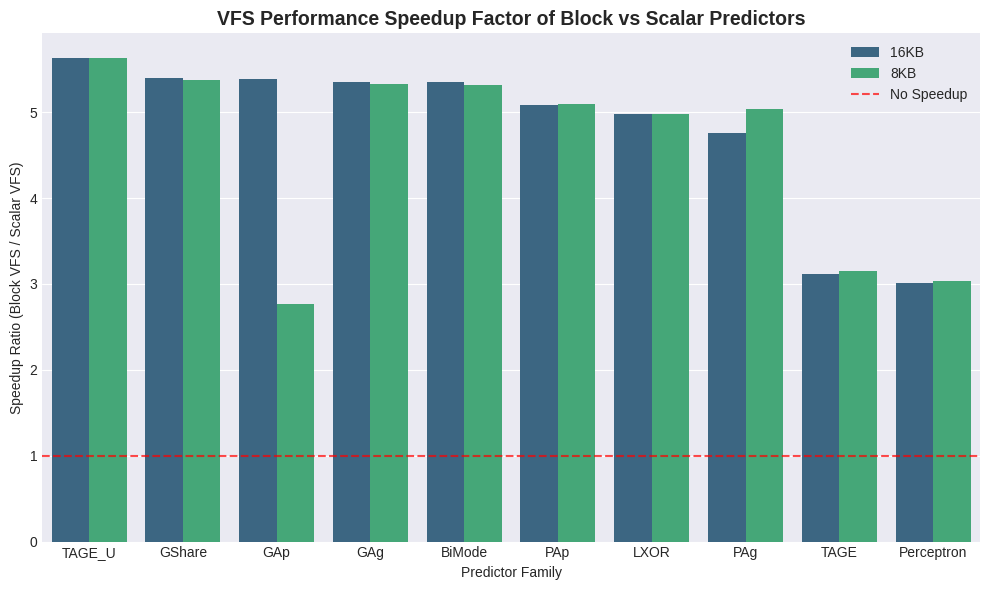

In [24]:
# Plot the speedup factor for 8KB and 16KB families
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=family_vfs, x='family', y='Speedup (Block/Scalar)', hue='budget', palette='viridis', ax=ax)
ax.set_title("VFS Performance Speedup Factor of Block vs Scalar Predictors", fontsize=14, fontweight='bold')
ax.set_ylabel("Speedup Ratio (Block VFS / Scalar VFS)")
ax.set_xlabel("Predictor Family")
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='No Speedup')
plt.legend()
plt.tight_layout()
plt.show()

## 5. How to Reproduce Results

To regenerate the CSV results used in this notebook:

1. **Trace Characterization CSV**:
   Run the trace analyzer tool:
   ```bash
   python3 profiling/scripts/analyze_traces.py --tracedir ./traces --jobs 16 --warmup 1000000 --measure 40000000
   ```
   This generates `profiling/outputs/trace_characteristics.csv` containing the branch stats of all 168 traces.
   
2. **Parameter Sweeps (Configurations Optimization)**:
   Run the parameter sweeper to identify optimal hardware-budget configurations:
   ```bash
   python3 profiling/scripts/run_sweeps.py --measure 5000000
   ```
   This updates `profiling/outputs/optimal_configs.json`.
   
3. **Master Predictor Comparison CSV**:
   Run the master comparison script on the 12 selected traces:
   ```bash
   python3 profiling/scripts/full_comparison.py --measure 10000000 --jobs 16
   ```
   This generates `profiling/outputs/full_comparison_results.csv`, which is loaded and analyzed in this notebook.